## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [Jaden Otchere]

**Date:** [09/30/2026]

**Q1.**
1. *What is the difference between regression and classification?*
- The difference is that regression predicts a numeric outcome, but classification predicts a category.

2. *What is a confusion table? What does it help us understand about a model's performance?*
- A confuson table is a table used to measure how well a classifictaion model is performing. It helps you understand where the model is making, by comparing predictions with actual results and shows where the model was right or wrong. 

3. *What does the SSE quantify about a particular model?*
- This measures total unexpected error.

4. *What are overfitting and underfitting?*
- Overfitting is when the mdoel learns too much from the training data including noise and outliers. Undefitting is when the model fails to learn important patterns. 

5. *Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?*
- This improves model performance because splitting the data allows us to test the model on unsen data, which in turn helps to choos a k that generlaizs better and avoids overfitting.

6. *With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.*
- *Predictions*
- Strength - This approach is simple, its easier to evaluate and communicate. It's usally non technical and users don't need to interpret anything.
- Weaknesses - it's less informative for training purposes. This approach alos hides uncertainties; users usually can't tell which predictions to trust.

- *Probability*
- Strength - this approach conveys more confidence. It's adaptble to change; for instance data changes probabilites can be reweighed.
- Weaknesses - probabilities may not be trustworthy. In general harder to interpret and communicate result; users may misread distributions over many classes because it can at times be overwhelming.

In [48]:
# Your Phase 1 solution to the problem goes here.
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("./data/land_mines.csv")

In [49]:
# 1. Exploratory Data Analysis (EDA)

#Organizing land mines by average voltage, soil, and average height

average_voltage = df.groupby('mine_type')['voltage'].mean().sort_values(ascending = False)
print("Average Voltage by Mine Type:")
print(average_voltage)

minetype_by_soil = df.groupby('mine_type')['soil'].mean().sort_values(ascending = False)
print("Soil of Mines:")
print(minetype_by_soil)


minetype_by_height = df.groupby('mine_type')['height'].mean().sort_values(ascending = False)
print("Height of Mines:")
print(minetype_by_height)

print(df.shape)


Average Voltage by Mine Type:
mine_type
2    0.721123
3    0.402408
5    0.379598
4    0.345365
1    0.296463
Name: voltage, dtype: float64
Soil of Mines:
mine_type
5    0.516923
2    0.508571
4    0.503030
3    0.496970
1    0.492958
Name: soil, dtype: float64
Height of Mines:
mine_type
5    0.530070
3    0.527548
4    0.506887
1    0.495519
2    0.487013
Name: height, dtype: float64
(338, 4)


In [50]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
#2. Split the sample 50/50 into training and test/validation sets

from sklearn.model_selection import train_test_split

x = df[['voltage', 'soil', 'height']]
y = df['mine_type']

x_train , x_test, y_train, y_test = train_test_split(x, y, test_size = 0.5, random_state = 42)

best k: 1


Text(0, 0.5, 'Accuracy')

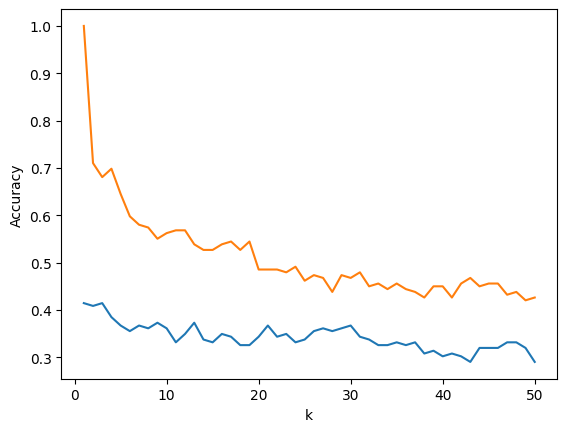

In [52]:
# 3. Build a $k$-NN classifier. Explain how you select $k$.
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler

k_NN = 2
classification_scaler = MinMaxScaler().fit(x_train)
classification_x_train_scaled = pd.DataFrame(classification_scaler.fit_transform(x_train), columns = x.columns, index = x_train.index)
classification_x_test_scaled = pd.DataFrame(classification_scaler.fit_transform(x_test), columns = x.columns, index = x_test.index)

classifictation_model = KNeighborsClassifier(n_neighbors = k_NN).fit(classification_x_scaled, y)


ks = np.arange(1,51)
test_acc, train_acc = [],[]

for k in ks:
    model = KNeighborsClassifier(n_neighbors = k).fit(classification_x_train_scaled, y_train)
    test_acc.append((model.predict(classification_x_test_scaled) == y_test.to_numpy()).mean())
    train_acc.append((model.predict(classification_x_train_scaled) == y_train.to_numpy()).mean())

k_target = ks[np.argmax(test_acc)]
print("best k:", k_target)

plt.plot(ks, test_acc, label = "Test Accuracy")
plt.plot(ks, train_acc, label = "Train Accuracy")
plt.xlabel("k")
plt.ylabel("Accuracy")



*So for the kNN classifier, I wnet with the method done in class. I tried every k from 1-50. For each one, I fit a kNN model on the training half and measure its accuracy on the kept out half. I picked the k with the highest accuracy.*

*Training accuracy can't be used for this, because at k= 1 each point is its own nearest neighbor, so accuracy is always 100%*

In [53]:
#4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
from sklearn.metrics import confusion_matrix

optimal_model = KNeighborsClassifier(n_neighbors = k_target).fit(classification_x_train_scaled, y_train)
pred = optimal_model.predict(classification_x_test_scaled)

print(pd.DataFrame(confusion_matrix(y_test, pred), index = optimal_model.classes_, columns = optimal_model.classes_))

print("accuracy:", (pred == y_test.to_numpy()).mean())



    1   2   3  4   5
1  16   0   5  5  11
2   0  25   1  5   2
3   4   2  12  3  11
4   5   3   7  9  12
5   4   0  12  7   8
accuracy: 0.41420118343195267


*Q.5*
I would advise them to treat the prediction like a screening or a triage. The fact that there is a "no mine" or "safe" prediction should not authorize entering an area wihput independent confirmation. Also when the mine is unsure between mine types assume it's the most dangerous one.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [4825221c1b0bd550adb8e9a4c001088f360618c8]
- **AI tool and model used:** [Claude]

### *Prompts used

1. [Looking at my solutions what are some ways I can asnwer the questions in a better way, as well as help any reader better undertsand the notebook through proper output.]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Use a stratified split (stratify=y) so both halves keep the same class proportions.
2. Report per-class recall and precision with classification_report alongside the confusion matrix.
3. Use predict_proba to flag uncertain predictions, to support the Q5 advice.
4. Add more EDA: class counts, per-class summary statistics, a pairplot, and a boxplot of voltage by mine type.
5. Show the confusion matrix as a heatmap as well as a table.
6. Try distance-weighted voting (weights='distance') and compare it with uniform voting.


### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept  | it keeps class proportions equal in both halves|
| 2| Accept | This shows where the model fails. Can also show if the numbers match the confusion table |
| 3| Accept | This supports the advice and helps verify uncertain predcitions and their accuracy  |
| 4| Accept | adding boxplots, sns, and pairplots because I belev it gives veiweres a better visualization of the data  |


### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

**Q1.**
1. *What is the difference between regression and classification?*
- The difference is that regression predicts a numeric outcome, but classification predicts a category.

2. *What is a confusion table? What does it help us understand about a model's performance?*
- A confuson table is a table used to measure how well a classifictaion model is performing. It helps you understand where the model is making, by comparing predictions with actual results and shows where the model was right or wrong. 

3. *What does the SSE quantify about a particular model?*
- This measures total unexpected error.

4. *What are overfitting and underfitting?*
- Overfitting is when the mdoel learns too much from the training data including noise and outliers. Undefitting is when the model fails to learn important patterns. 

5. *Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?*
- This improves model performance because splitting the data allows us to test the model on unsen data, which in turn helps to choos a k that generlaizs better and avoids overfitting.

6. *With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.*
- *Predictions*
- Strength - This approach is simple, its easier to evaluate and communicate. It's usally non technical and users don't need to interpret anything.
- Weaknesses - it's less informative for training purposes. This approach alos hides uncertainties; users usually can't tell which predictions to trust.

- *Probability*
- Strength - this approach conveys more confidence. It's adaptble to change; for instance data changes probabilites can be reweighed.
- Weaknesses - probabilities may not be trustworthy. In general harder to interpret and communicate result; users may misread distributions over many classes because it can at times be overwhelming.

In [54]:
# Your Phase 2 solution to the problem goes here.
# Your Phase 1 solution to the problem goes here.
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("./data/land_mines.csv")

(338, 4)
          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
            voltage                soil              height          
               mean       std      mean       std      mean       std
mine_type                                                            
1          0.296463  0.031672  0.492958  0.341143  0.495519  0.315962
2          0.721123  0.222267  0.508571  0.345045  0.487013  0.310720
3          0.402408  0.098185  0.496970  0.351248  0.527548  0.296288
4        

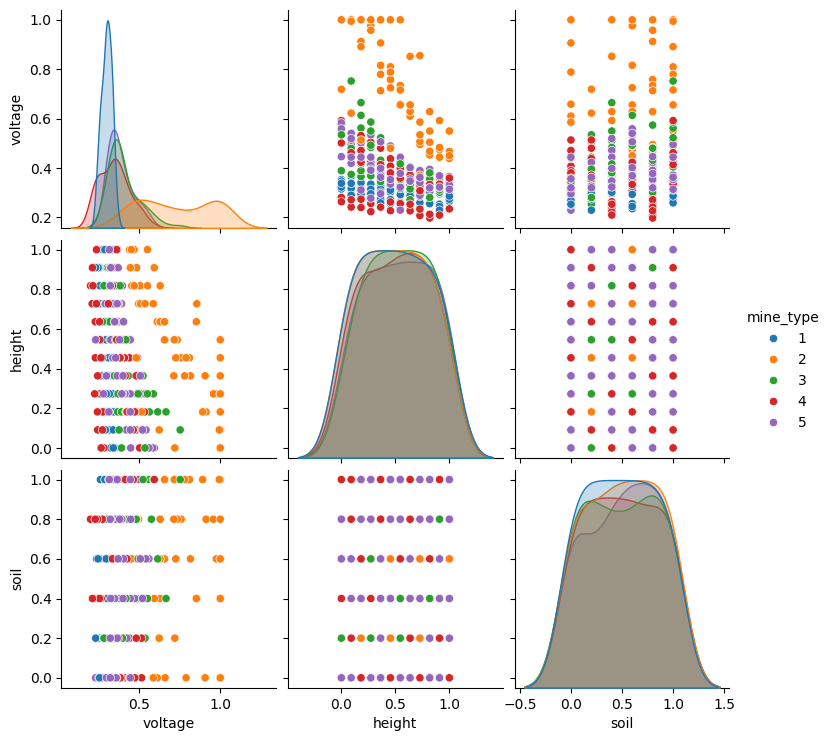

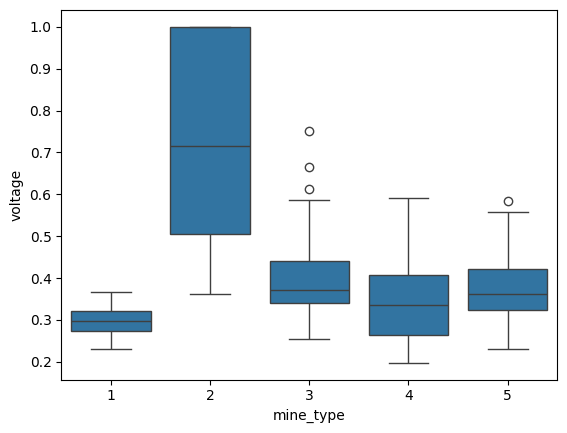

In [55]:
# 1. Exploratory Data Analysis (EDA)

#Organizing land mines by average voltage, soil, and average height
print(df.shape)
print(df.describe())
print(df['mine_type'].value_counts().sort_index())
print(df.groupby("mine_type")[["voltage", "soil", "height"]].agg(["mean", "std"]))

sns.pairplot(df, hue = "mine_type", palette = "tab10")
plt.show()

sns.boxplot(data = df, x = "mine_type", y = "voltage")
plt.show()


In [56]:
#2. Split the sample 50/50 into training and test/validation sets

from sklearn.model_selection import train_test_split

x = df[['voltage', 'soil', 'height']]
y = df['mine_type']

x_train , x_test, y_train, y_test = train_test_split(x, y, test_size = 0.5, random_state = 42, stratify = y)

best k: 2


Text(0, 0.5, 'Accuracy')

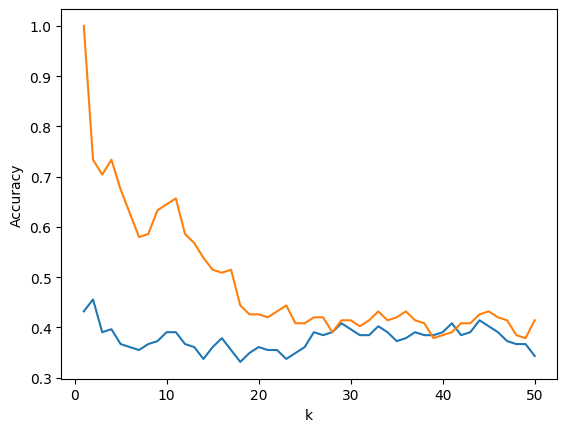

In [57]:
# 3. Build a $k$-NN classifier. Explain how you select $k$.
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler

k_NN = 2
classification_scaler = MinMaxScaler().fit(x_train)
classification_x_train_scaled = pd.DataFrame(classification_scaler.fit_transform(x_train), columns = x.columns, index = x_train.index)
classification_x_test_scaled = pd.DataFrame(classification_scaler.fit_transform(x_test), columns = x.columns, index = x_test.index)

classifictation_model = KNeighborsClassifier(n_neighbors = k_NN).fit(classification_x_scaled, y)


ks = np.arange(1,51)
test_acc, train_acc = [],[]

for k in ks:
    model = KNeighborsClassifier(n_neighbors = k).fit(classification_x_train_scaled, y_train)
    test_acc.append((model.predict(classification_x_test_scaled) == y_test.to_numpy()).mean())
    train_acc.append((model.predict(classification_x_train_scaled) == y_train.to_numpy()).mean())

k_target = ks[np.argmax(test_acc)]
print("best k:", k_target)

plt.plot(ks, test_acc, label = "Test Accuracy")
plt.plot(ks, train_acc, label = "Train Accuracy")
plt.xlabel("k")
plt.ylabel("Accuracy")




In [58]:
#4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
#4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

optimal_model = KNeighborsClassifier(n_neighbors = k_target).fit(classification_x_train_scaled, y_train)
pred = optimal_model.predict(classification_x_test_scaled)

print(pd.DataFrame(confusion_matrix(y_test, pred), index = optimal_model.classes_, columns = optimal_model.classes_))

print("accuracy:", (pred == y_test.to_numpy()).mean())

print(classification_report(y_test, pred))

    1   2   3  4  5
1  26   0   6  4  0
2   0  32   0  3  0
3  10   1  12  7  3
4  10   6  10  7  0
5   8   1  15  8  0
accuracy: 0.4556213017751479
              precision    recall  f1-score   support

           1       0.48      0.72      0.58        36
           2       0.80      0.91      0.85        35
           3       0.28      0.36      0.32        33
           4       0.24      0.21      0.23        33
           5       0.00      0.00      0.00        32

    accuracy                           0.46       169
   macro avg       0.36      0.44      0.39       169
weighted avg       0.37      0.46      0.41       169



*Q.5*
I would advise them to treat the prediction like a screening or a triage. The fact that there is a "no mine" or "safe" prediction should not authorize entering an area wihput independent confirmation. Also when the mine is unsure between mine types assume it's the most dangerous one.

In [59]:
probs = optimal_model.predict_proba(classification_x_test_scaled)
uncertain = probs.max(axis = 1) < 0.6
print("share of uncertain predictions:", uncertain.mean())
print("accuracy of uncertain predictions:", (pred[~uncertain] == y_test.to_numpy()[~uncertain]).mean())

share of uncertain predictions: 0.6390532544378699
accuracy of uncertain predictions: 0.5573770491803278


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

The main improvements in my solutions were the optimization of different parts of the code in phase 1, as well as the expouding in te visualization of the data. More specificly I *straify* to the train_test_split function and this made the class proportions equal in both havles of the test and train. I also completely re did my EDA, many ways the same, however I belive that flow of information is better. Also there are far more graphs which will help the audience visualize the information better, and benefit us in tellign a better story. There wern't any grave mistakes i the AI. I verified the solution, by chekcing bakc with the slides and comparing how AI implemented things with how we originally learned them. I also did commone sense checks, if something didn't aling after checking with visualizations and other EDA tactics, then I would take a second look at those things.